## Installing Qiskit

In [ ]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 111.4 MB/s eta 0:00:00


## Importing Python packages

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from numpy import asarray
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile, assemble
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.circuit.library import RYGate
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import time
import math

## Simulation Setup

In [ ]:
backend_sim = AerSimulator()
def run_simulation(circuit, backend, nshots=8192):
    circuit = transpile(circuit, backend, optimization_level=1)

    job_sim = backend.run(circuit, shots=nshots)
    job_sim.wait_for_final_state(timeout=None, wait=5, callback=None)

    result_sim = job_sim.result()
    counts_sim = result_sim.get_counts(circuit)

    return counts_sim

def run_simulation_statevector(qc):
    # Simulating circuits
    qc.remove_final_measurements()  # no measurements allowed

    statevector = Statevector(qc)
    return statevector

## Image Pre-Processing

In [ ]:
def load_and_display_image(image_path, display_img=True, invert = False):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if invert:
        image = 255 - image
    # image = np.array(image) / 255
    if display_img:
        plt.imshow(image)
        plt.axis('off')
        plt.show()
    return image

def resize_image(image, new_size=(64, 64)):
    resized_image = cv2.resize(image, new_size, interpolation=cv2.INTER_NEAREST)
    return resized_image

def crop_image(image, new_size=(64, 64)):
    croped_image = image[0:new_size[0], 0:new_size[1]]
    return croped_image

def save_image(image, file_name = None):
    plt.imsave(file_name, image,cmap='gray')

def plot_image(image, title):
    size_img = np.shape(image)
    title = title + " " + str(size_img)

    plt.imshow(image, extent=[0,image.shape[0], image.shape[1],0,], cmap='gray')
    plt.xticks(range(0,image.shape[0],2))
    plt.yticks(range(0,image.shape[1],2))
    plt.axis('off')
    plt.title(title)
    plt.show()

def plot_images(images, titles):
    size_img = np.shape(images[0])
    f, axarr = plt.subplots(1,len(images), figsize=(15,3*len(images)))
    # f, axarr = plt.subplots(1,len(images))

    for i in range(len(images)):
        title = titles[i] + " " + str(size_img)
        axarr[i].set_title(title)
        axarr[i].set_xticks(range(0,images[i].shape[0],10))
        axarr[i].set_yticks(range(0,images[i].shape[1],10))
        axarr[i].imshow(images[i], cmap='gray')
        axarr[i].axis('off')

    plt.show()

## QPIE and FRQI Encoding Decoding Functions

### QPIE

In [ ]:
# Assuming the picture is of size: 2^n x 2^n
# The num. of qubits depends on 2n, where n is taken from picture size.
# E.g.: n=1 -> 2^1 x 2^1 -> 2 x 2 -> qubit_num = 2*1 = 2

###################################################################
########################### QPIE encoding ###########################
def qpie(img, measure = True):
    img = img/np.linalg.norm(img)

    image_array=np.asarray(img).flatten()
    qubit_num = int(np.log2(len(image_array)))

    position_qubits = QuantumRegister(qubit_num, 'position')
    classical_bits = ClassicalRegister(qubit_num, 'classical')
    qc = QuantumCircuit(position_qubits, classical_bits)

    qc.initialize(image_array,range(qubit_num))
    if measure:
        qc.measure_all(add_bits=False)
        return qc
    else:
        return qc, position_qubits, classical_bits, qubit_num

def retrieve_image_qpie(counts):
    n = (len(next(iter(counts))))// 2 # Get n (qubit_num) from the first dict key length

    image = np.zeros((2**n)**2)
    count_sum = np.sum([val for val in counts.values()])

    # Adding measurements to the image array
    for key, value in counts.items():
        # value/count_sum = p_i
        # sqrt{pi} = I_i/norm(I)
        image[int(key,2)] = ((value/count_sum)**(0.5))

    image = image.reshape((2**n,2**n))

    return image

### FRQI

In [ ]:
###################################################################
########################### FRQI encoding ###########################
# Assuming the picture is of size: 2^n x 2^n
# The num. of qubits depends on 2n+1, where n is taken from picture size.
# E.g.: n=1 -> 2^1 x 2^1 -> 2 x 2 -> qubit_num = 2*1+1 = 3

def frqi(image, measure = True):
    image_array=np.asarray(image).flatten()
    qubit_num = int(np.log2(len(image_array)))

    pixel_qubit = QuantumRegister(1, 'pixel qubit')
    pos_qubits = QuantumRegister(qubit_num, 'position qubit')
    classical_bits = ClassicalRegister(qubit_num + 1, 'classical')
    qc = QuantumCircuit(pixel_qubit,pos_qubits, classical_bits)

    image_array = image_array / 255.0 ### Normalizing grayscale values
    theta_values = [math.asin(image_array[k]) for k in range(len(image_array))]

    enc_state = [] ### Form: psi = cos(t)|i>|0> + sin(t)|i>|1>
    for k in range(0,2**(qubit_num+1),2):
      enc_state.append(np.cos(theta_values[int(k/2)]))
      enc_state.append(np.sin(theta_values[int(k/2)]))

    enc_state = np.asarray(enc_state)
    enc_state = enc_state/(2**(qubit_num/2))

    qc.initialize(enc_state,range(qubit_num+1))

    if measure:
        qc.measure_all(add_bits=False)
        return qc
    else:
        return qc

def retrieve_image_frqi(counts):
    n = (len(next(iter(counts))) - 1)//2 # Get n (qubit_num) from the first dict key length

    image = np.zeros((2**n)**2)
    count_sum = np.sum([val for val in counts.values()])
    # Adding measurements to the image array
    for key, value in counts.items():
        if key[-1] == "1":
            ### Last qubit -  Ancilla qubit
            ### If 1: sin(ti)
            ### If 0: cos(ti)
            image[int(key[:-1],2)] = ((value/count_sum)**(0.5))*255*(2**n)

    image = image.reshape((2**n,2**n))

    return image

## Connecting to the QHCD folder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import sys
# sys.path.append('./drive/MyDrive/QHCD')

pixel_size = [64, 128, 512, 1024]
n_shots = [int(1e3),5*int(1e3),int(1e4),5*int(1e4),int(1e5),5*int(1e5),int(1e6),5*int(1e6),int(1e7),5*int(1e7),int(1e8),5*int(1e8)]
# n_shots = [int(1e3),int(1e4),int(1e5),int(1e6),int(1e7),int(1e8)]

pixel_size_num = len(pixel_size)
n_shots_num = len(n_shots)

dataset_path = Path('./drive/MyDrive/QHCD')
file_count = 0
for entry in dataset_path.iterdir():
      if entry.is_file() and entry.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
        print("Image File: ", entry.name)

        image_path = dataset_path / entry.name
        test_image = load_and_display_image(image_path,display_img = False)
        for i_p in range(pixel_size_num):
          image = resize_image(test_image, (pixel_size[i_p],pixel_size[i_p]))
          ### Saving reconstructed image
          if image.dtype != np.uint8: ### Saving 8-bit grayscale images
            image = image.astype(np.uint8)

          file_name = f"Original_{entry.stem}_{pixel_size[i_p]}{entry.suffix}"
          output_path = dataset_path/ 'Simulation results' / file_name
          img_out = Image.fromarray(image, 'L') # 'L' mode for grayscale
          img_out.save(output_path)

        file_count = file_count + 1

print("\n Number of Test Images: ", file_count)


Image File:  CAT_1.webp

 Number of Test Images:  1


## Quantum Image Processing using QPIE

In [ ]:
rmse_QPIE = np.zeros((file_count,pixel_size_num,n_shots_num))
ssim_value_QPIE = np.zeros((file_count,pixel_size_num,n_shots_num))
relative_diff_QPIE = np.zeros((file_count,pixel_size_num,n_shots_num))
i_file = 0

# Iterate over all files in the dataset
for entry in dataset_path.iterdir():
    # Optionally, filter to only process image files based on their extension
    if entry.is_file() and entry.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
        print("\n Image File: ", entry.name)

        img_file = entry.name
        # img_name = img_file.split('.')[0]  # Split by '.' and take the first part
        # otherwise use entry.stem (name of the file without extension)

        image_path = dataset_path / img_file
        test_image = load_and_display_image(image_path,display_img = False)

        print("\n --------------------------------------- \n")
        for i_p in range(pixel_size_num):
          print("\n Image Size: ", pixel_size[i_p], "x", pixel_size[i_p])
          image = resize_image(test_image, (pixel_size[i_p],pixel_size[i_p]))
          plot_image(image,entry.name)

          for i_s in range(n_shots_num):
            print("\n Number of shots: ", n_shots[i_s])

            ##### Encoding

            print("\n Performing QPIE Encoding ----- ")
            qc_QPIE = qpie(image)
            # print(type(qc_QPIE))
            # print(qc_QPIE.draw())

            print("QPIE Encoding Complete! ")


            ##### Decoding
            print("\n Performing QPIE Simulation ----- ")
            start_time = time.perf_counter()
            counts_sim_QPIE = run_simulation(qc_QPIE, backend_sim, nshots=n_shots[i_s])
            end_time = time.perf_counter()
            elapsed_seconds = end_time - start_time
            print(f"QPIE Simulation Complete! Elapsed time: {elapsed_seconds:.6f} seconds\n")

            print("\n Performing QPIE Decoding ----- ")
            image_out_QPIE = retrieve_image_qpie(counts_sim_QPIE)
            image_out_QPIE = image_out_QPIE*np.linalg.norm(image)

            print("QPIE Decoding Complete! ")

            plot_images([image,image_out_QPIE],["Original Image", " QPIE Image"])

            ### Calculating Performance Metrics
            img1_gray = image.astype("float")
            # img1_gray = img1_gray / np.linalg.norm(img1_gray)
            img2_gray = image_out_QPIE.astype("float")

            # Compute RMSE
            mse = np.mean((img1_gray - img2_gray) ** 2)
            rmse_QPIE[i_file,i_p,i_s] = np.sqrt(mse)

            # Compute SSIM; set multichannel=False because we're using grayscale
            ssim_value_QPIE[i_file,i_p,i_s], ssim_image = structural_similarity(img1_gray, img2_gray, full=True,data_range=255)
            # ssim_value_QPIE[i_file,i_p,i_s], ssim_image = structural_similarity(img1_gray, img2_gray, full=True,data_range=np.max(img2_gray)-np.min(img2_gray)) ### if using normalized image

            # Compute Relative Difference
            relative_diff_QPIE[i_file,i_p,i_s] = np.sum(np.abs(img1_gray - img2_gray)) / np.sum(np.abs(img1_gray))

            print("\n Performance Evaluations: \n")
            print("Relative Difference:", relative_diff_QPIE[i_file,i_p,i_s])
            print("RMSE:", rmse_QPIE[i_file,i_p,i_s])
            print("SSIM:", ssim_value_QPIE[i_file,i_p,i_s])

            ### Saving reconstructed image
            # if image_out_QPIE.dtype != np.uint8: ### Saving 8-bit grayscale images
            #   image_out_QPIE = image_out_QPIE.astype(np.uint8)

            nshots_temp = len(str(n_shots[i_s]))-1

            img_output_name = f"QPIE_{entry.stem}_{pixel_size[i_p]}_shots_{nshots_temp}{entry.suffix}"
            output_path = dataset_path / 'Simulation results' / img_output_name
            # save_image(image_out_QPIE, file_name = output_path)

            # img_out = Image.fromarray(image_out_QPIE, 'L') # 'L' mode for grayscale
            # img_out.save(output_path)

        i_file = i_file + 1

Output hidden; open in https://colab.research.google.com to view.


 Image File:  CAT_1.webp


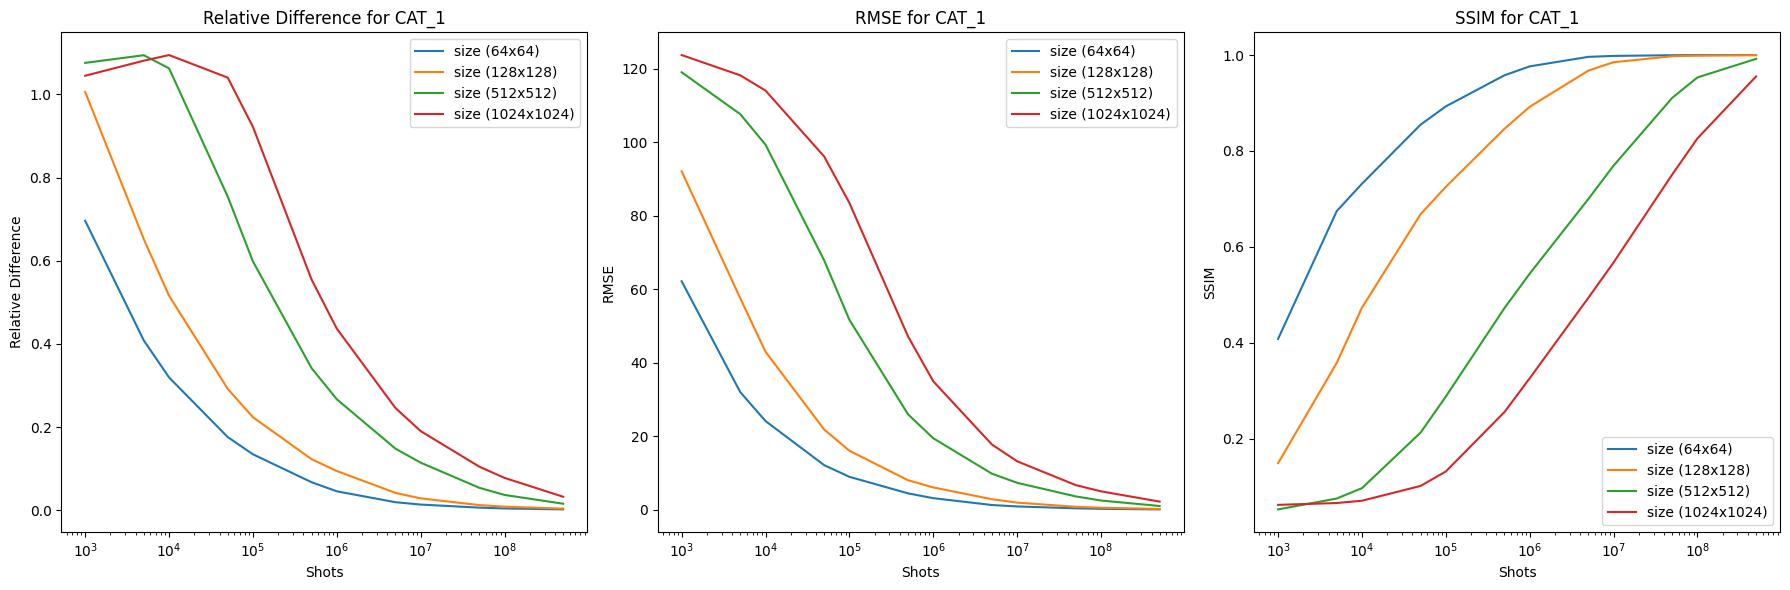

In [ ]:
# For each image, create a figure with 3 subplots (1 row, 3 columns)
# Iterate over all files in the dataset
img_idx = 0
for entry in dataset_path.iterdir():
    # Optionally, filter to only process image files based on their extension
    if entry.is_file() and entry.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
        print("\n Image File: ", entry.name)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1x3 subplot

        # Subplot 1: Relative Difference
        ax = axes[0]
        for pixel_idx in range(pixel_size_num):
            ax.plot(n_shots, relative_diff_QPIE[img_idx, pixel_idx, :],
                    label=f'size ({pixel_size[pixel_idx]}x{pixel_size[pixel_idx]})')
        ax.set_xscale('log')  # Set x-axis to log10 scale
        ax.set_xlabel('Shots')
        ax.set_ylabel('Relative Difference')
        ax.set_title(f'Relative Difference for {entry.stem}')
        if pixel_size_num <= 10:
            ax.legend()

        # Subplot 2: RMSE
        ax = axes[1]
        for pixel_idx in range(pixel_size_num):
            ax.plot(n_shots, rmse_QPIE[img_idx, pixel_idx, :],
                    label=f'size ({pixel_size[pixel_idx]}x{pixel_size[pixel_idx]})')
        ax.set_xscale('log')  # Set x-axis to log10 scale
        ax.set_xlabel('Shots')
        ax.set_ylabel('RMSE')
        ax.set_title(f'RMSE for {entry.stem}')
        if pixel_size_num <= 10:
            ax.legend()

        # Subplot 3: SSIM
        ax = axes[2]
        for pixel_idx in range(pixel_size_num):
            ax.plot(n_shots, ssim_value_QPIE[img_idx, pixel_idx, :],
                    label=f'size ({pixel_size[pixel_idx]}x{pixel_size[pixel_idx]})')
        ax.set_xscale('log')  # Set x-axis to log10 scale
        ax.set_xlabel('Shots')
        ax.set_ylabel('SSIM')
        ax.set_title(f'SSIM for {entry.stem}')
        if pixel_size_num <= 10:
            ax.legend()

        plt.tight_layout()  # Adjust subplots to fit into the figure area.
        plt.show()

        img_idx = img_idx + 1

## Quantum Image Processing using FRQI

In [ ]:
rmse_FRQI = np.zeros((file_count,pixel_size_num,n_shots_num))
ssim_value_FRQI = np.zeros((file_count,pixel_size_num,n_shots_num))
relative_diff_FRQI = np.zeros((file_count,pixel_size_num,n_shots_num))
i_file = 0

# Iterate over all files in the dataset
for entry in dataset_path.iterdir():
    # Optionally, filter to only process image files based on their extension
    if entry.is_file() and entry.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
        print("\n Image File: ", entry.name)

        img_file = entry.name
        # img_name = img_file.split('.')[0]  # Split by '.' and take the first part
        # otherwise use entry.stem (name of the file without extension)

        image_path = dataset_path / img_file
        test_image = load_and_display_image(image_path,display_img = False)

        print("\n --------------------------------------- \n")
        for i_p in range(pixel_size_num):
          print("\n Image Size: ", pixel_size[i_p], "x", pixel_size[i_p])
          image = resize_image(test_image, (pixel_size[i_p],pixel_size[i_p]))
          plot_image(image,entry.name)

          for i_s in range(n_shots_num):
            print("\n Number of shots: ", n_shots[i_s])

            ##### Encoding

            print("\n Performing FRQI Encoding ----- ")
            qc_FRQI = frqi(image)
            # print(type(qc_FRQI))
            # print(qc_FRQI.draw())

            print("FRQI Encoding Complete! ")


            ##### Decoding
            print("\n Performing FRQI Simulation ----- ")
            start_time = time.perf_counter()
            counts_sim_FRQI = run_simulation(qc_FRQI, backend_sim, nshots=n_shots[i_s])
            end_time = time.perf_counter()
            elapsed_seconds = end_time - start_time
            print(f"FRQI Simulation Complete! Elapsed time: {elapsed_seconds:.6f} seconds\n")

            print("\n Performing FRQI Decoding ----- ")
            image_out_FRQI = retrieve_image_frqi(counts_sim_FRQI)

            print("FRQI Decoding Complete! ")

            plot_images([image,image_out_FRQI],["Original Image", " FRQI Image"])

            ### Calculating Performance Metrics
            img1_gray = image.astype("float")
            img2_gray = image_out_FRQI.astype("float")

            # Compute RMSE
            mse = np.mean((img1_gray - img2_gray) ** 2)
            rmse_FRQI[i_file,i_p,i_s] = np.sqrt(mse)

            # Compute SSIM; set multichannel=False because we're using grayscale
            ssim_value_FRQI[i_file,i_p,i_s], ssim_image = structural_similarity(img1_gray, img2_gray, full=True,data_range=255)

            # Compute Relative Difference
            relative_diff_FRQI[i_file,i_p,i_s] = np.sum(np.abs(img1_gray - img2_gray)) / np.sum(np.abs(img1_gray))

            print("\n Performance Evaluations: \n")
            print("Relative Difference:", relative_diff_FRQI[i_file,i_p,i_s])
            print("RMSE:", rmse_FRQI[i_file,i_p,i_s])
            print("SSIM:", ssim_value_FRQI[i_file,i_p,i_s])

            ### Saving reconstructed image
            # if image_out_FRQI.dtype != np.uint8: ### Saving 8-bit grayscale images
            #   image_out_FRQI = image_out_FRQI.astype(np.uint8)

            nshots_temp = len(str(n_shots[i_s]))-1

            img_output_name = f"FRQI_{entry.stem}_{pixel_size[i_p]}_shots_{nshots_temp}{entry.suffix}"
            output_path = dataset_path / 'Simulation results' / img_output_name
            save_image(image_out_FRQI, file_name = output_path)
            # img_out = Image.fromarray(image_out_FRQI, 'L') # 'L' mode for grayscale
            # img_out.save(output_path)

        i_file = i_file + 1

Output hidden; open in https://colab.research.google.com to view.


 Image File:  CAT_1.webp


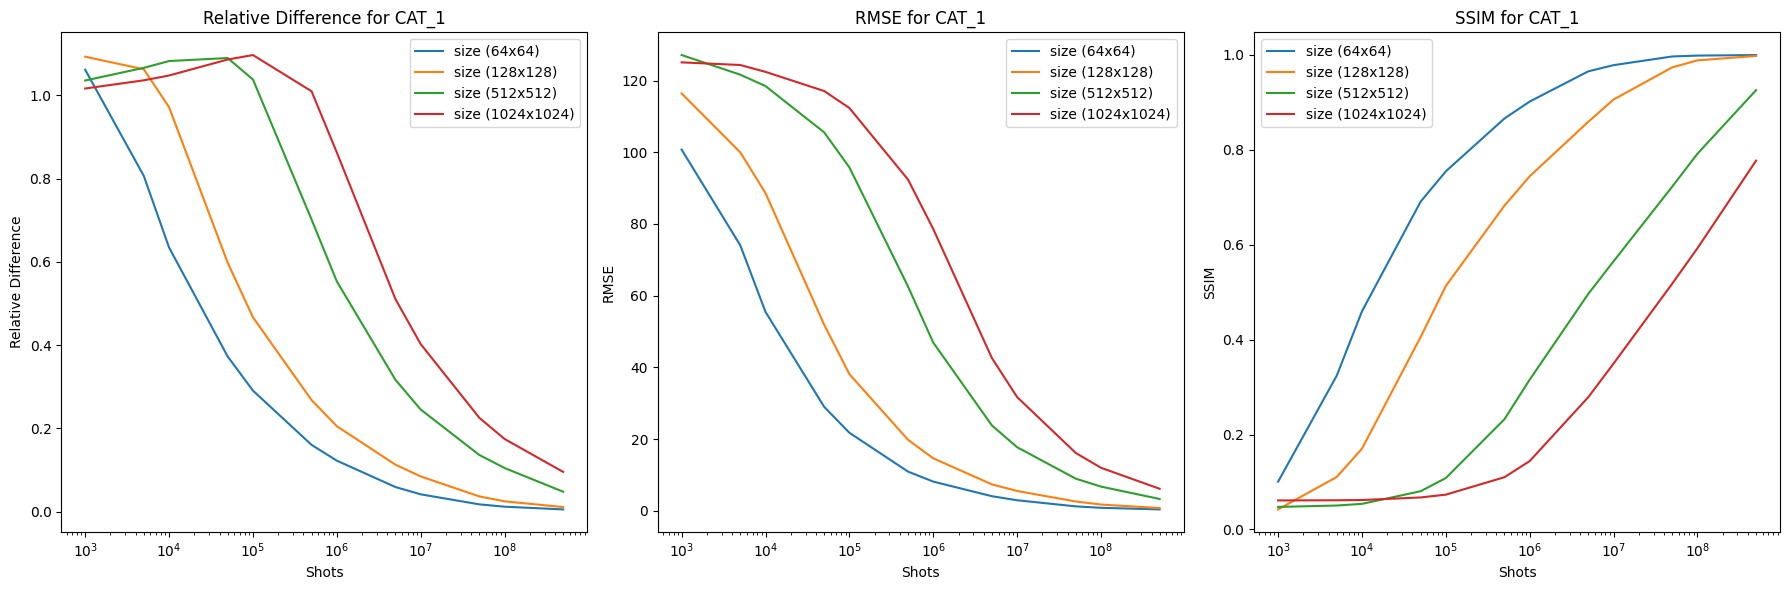

In [ ]:
# For each image, create a figure with 3 subplots (1 row, 3 columns)
# Iterate over all files in the dataset
img_idx = 0
for entry in dataset_path.iterdir():
    # Optionally, filter to only process image files based on their extension
    if entry.is_file() and entry.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
        print("\n Image File: ", entry.name)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1x3 subplot

        # Subplot 1: Relative Difference
        ax = axes[0]
        for pixel_idx in range(pixel_size_num):
            ax.plot(n_shots, relative_diff_FRQI[img_idx, pixel_idx, :],
                    label=f'size ({pixel_size[pixel_idx]}x{pixel_size[pixel_idx]})')
        ax.set_xscale('log')  # Set x-axis to log10 scale
        ax.set_xlabel('Shots')
        ax.set_ylabel('Relative Difference')
        ax.set_title(f'Relative Difference for {entry.stem}')
        if pixel_size_num <= 10:
            ax.legend()

        # Subplot 2: RMSE
        ax = axes[1]
        for pixel_idx in range(pixel_size_num):
            ax.plot(n_shots, rmse_FRQI[img_idx, pixel_idx, :],
                    label=f'size ({pixel_size[pixel_idx]}x{pixel_size[pixel_idx]})')
        ax.set_xscale('log')  # Set x-axis to log10 scale
        ax.set_xlabel('Shots')
        ax.set_ylabel('RMSE')
        ax.set_title(f'RMSE for {entry.stem}')
        if pixel_size_num <= 10:
            ax.legend()

        # Subplot 3: SSIM
        ax = axes[2]
        for pixel_idx in range(pixel_size_num):
            ax.plot(n_shots, ssim_value_FRQI[img_idx, pixel_idx, :],
                    label=f'size ({pixel_size[pixel_idx]}x{pixel_size[pixel_idx]})')
        ax.set_xscale('log')  # Set x-axis to log10 scale
        ax.set_xlabel('Shots')
        ax.set_ylabel('SSIM')
        ax.set_title(f'SSIM for {entry.stem}')
        if pixel_size_num <= 10:
            ax.legend()

        plt.tight_layout()  # Adjust subplots to fit into the figure area.
        plt.show()

        img_idx = img_idx + 1

## Saving Metrics for QPIE and FRQI

In [ ]:
# Save the arrays as .npy files in the output folder
np.save(dataset_path / 'Simulation results' / 'Metrics' / 'rmse_QPIE.npy', rmse_QPIE)
np.save(dataset_path / 'Simulation results' / 'Metrics' /' ssim_QPIE.npy', ssim_value_QPIE)
np.save(dataset_path / 'Simulation results' / 'Metrics' / 'relative_diff_QPIE.npy', relative_diff_QPIE)

np.save(dataset_path / 'Simulation results' / 'Metrics' / 'rmse_FRQI.npy', rmse_FRQI)
np.save(dataset_path / 'Simulation results' / 'Metrics' / 'ssim_FRQI.npy', ssim_value_FRQI)
np.save(dataset_path / 'Simulation results' / 'Metrics' / 'relative_diff_FRQI.npy', relative_diff_FRQI)

print("Metrics saved successfully!")

Metrics saved successfully!
